### Variables de la distribución normal

In [1]:
import copy
import random
import numpy as np
from scipy.stats import truncnorm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from funciones_utiles import train_LR, User, error_3groups, create_user_homophily_3groups, plot_theta_histogram_3groups, plot_user_checkpoints_3groups, plot_boxplots_3groups

# g1: mu = 0.7, std = 0.15
# g2: mu = 0.3, std = 0.15

# Intervalo de theta y x
a, b = 0, 1

# Media y desviación estándar de grupo 1
mu_g1 = 0.7
std_g1 = 0.15
a_g1 = (a - mu_g1) / std_g1
b_g1 = (b - mu_g1) / std_g1

# Media y desviación estándar de grupo 2
mu_g2 = 0.3
std_g2 = 0.15
a_g2 = (a - mu_g2) / std_g2
b_g2 = (b - mu_g2) / std_g2

# Añado grupo 3 con su media y desviación estándar
mu_g3 = 0.5
std_g3 = 0.15
a_g3 = (a - mu_g3) / std_g3
b_g3 = (b - mu_g3) / std_g3

### Creación de dataset sintético inicial

In [2]:
# Creación de dataset sintético inicial para entrenar el modelo

X = []
Y = []

# Meto muestras pertenecientes a G1
for i in range(333):
    x = truncnorm.rvs(a_g1, b_g1, loc=mu_g1, scale=std_g1)
    y = np.random.binomial(1, x)
    X.append(x)
    Y.append(y)

# Meto muestras pertenecientes a G2
for i in range(333):
    x = truncnorm.rvs(a_g2, b_g2, loc=mu_g2, scale=std_g2)
    y = np.random.binomial(1, x)
    X.append(x)
    Y.append(y)
    
# Meto muestras pertenecientes a G3
for i in range(333):
    x = truncnorm.rvs(a_g3, b_g3, loc=mu_g3, scale=std_g3)
    y = np.random.binomial(1, x)
    X.append(x)
    Y.append(y)
    
# guardo los X e y iniciales para las simulaciones siguientes
X = np.array(X).reshape(-1, 1)
y = np.array(Y)
print(X.shape, y.shape)

X_start = copy.deepcopy(X)
y_start = copy.deepcopy(y)

(999, 1) (999,)


### Creación de dataset sintético ruidoso inicial

In [3]:
# Creación de dataset sintético inicial para entrenar el modelo (y con ruido)

X = []
Y = []

# Meto muestras pertenecientes a G1
for i in range(333):
    x = truncnorm.rvs(a_g1, b_g1, loc=mu_g1, scale=std_g1)
    x_error = truncnorm.rvs((0-x)/1, (1-x)/1, loc=x, scale=1)
    y = np.random.binomial(1, x_error)
    X.append(x)
    Y.append(y)

# Meto muestras pertenecientes a G2
for i in range(333):
    x = truncnorm.rvs(a_g2, b_g2, loc=mu_g2, scale=std_g2)
    x_error = truncnorm.rvs((0-x)/1, (1-x)/1, loc=x, scale=1)
    y = np.random.binomial(1, x_error)
    X.append(x)
    Y.append(y)

# Meto muestras pertenecientes a G2
for i in range(333):
    x = truncnorm.rvs(a_g3, b_g3, loc=mu_g3, scale=std_g3)
    x_error = truncnorm.rvs((0-x)/1, (1-x)/1, loc=x, scale=1)
    y = np.random.binomial(1, x_error)
    X.append(x)
    Y.append(y)

# guardo los X e y iniciales ruidosos para las simulaciones siguientes
X = np.array(X).reshape(-1, 1)
y = np.array(Y)
print(X.shape, y.shape)

X_noisy_start = copy.deepcopy(X)
y_noisy_start = copy.deepcopy(y)

(999, 1) (999,)


### Entrenamiento del modelo inicial

In [4]:
# Entreno logistic regression inicial
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)

# Separar entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Crear y entrenar modelo
model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
#print("Probabilidades estimadas:", y_prob)

Accuracy: 0.6366666666666667
Matriz de confusión:
[[99 60]
 [49 92]]


In [5]:
# hago una copia del modelo inicial para futuras simulaciones
initial_model = copy.deepcopy(model)

### Entrenamiento del modelo ruidoso inicial

In [6]:
# Entreno logistic regression inicial
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)

# Separar entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Crear y entrenar modelo
noisy_model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
noisy_model.fit(X_train, y_train)

# Predicción
y_pred = noisy_model.predict(X_test)
y_prob = noisy_model.predict_proba(X_test)[:, 1]

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
#print("Probabilidades estimadas:", y_prob)

Accuracy: 0.4666666666666667
Matriz de confusión:
[[82 72]
 [88 58]]


In [7]:
# hago una copia del modelo inicial para futuras simulaciones
initial_noisy_model = copy.deepcopy(noisy_model)

### Creación de población inicial

In [8]:
n = 1000
population = []

for i in range(n):
    group = np.random.choice([1,2,3], p=[1/3, 1/3, 1/3])

    if group == 1:
        theta = truncnorm.rvs(a_g1, b_g1, loc=mu_g1, scale=std_g1)
    elif group == 2:
        theta = truncnorm.rvs(a_g2, b_g2, loc=mu_g2, scale=std_g2)
    else:
        theta = truncnorm.rvs(a_g3, b_g3, loc=mu_g3, scale=std_g3)

    x = theta
    user = User(i, group, theta, x)
    population.append(user)

In [9]:
# copio la poblacion inicial para reproducibilidad en 
# siguientes experimentos 
initial_population = copy.deepcopy(population)

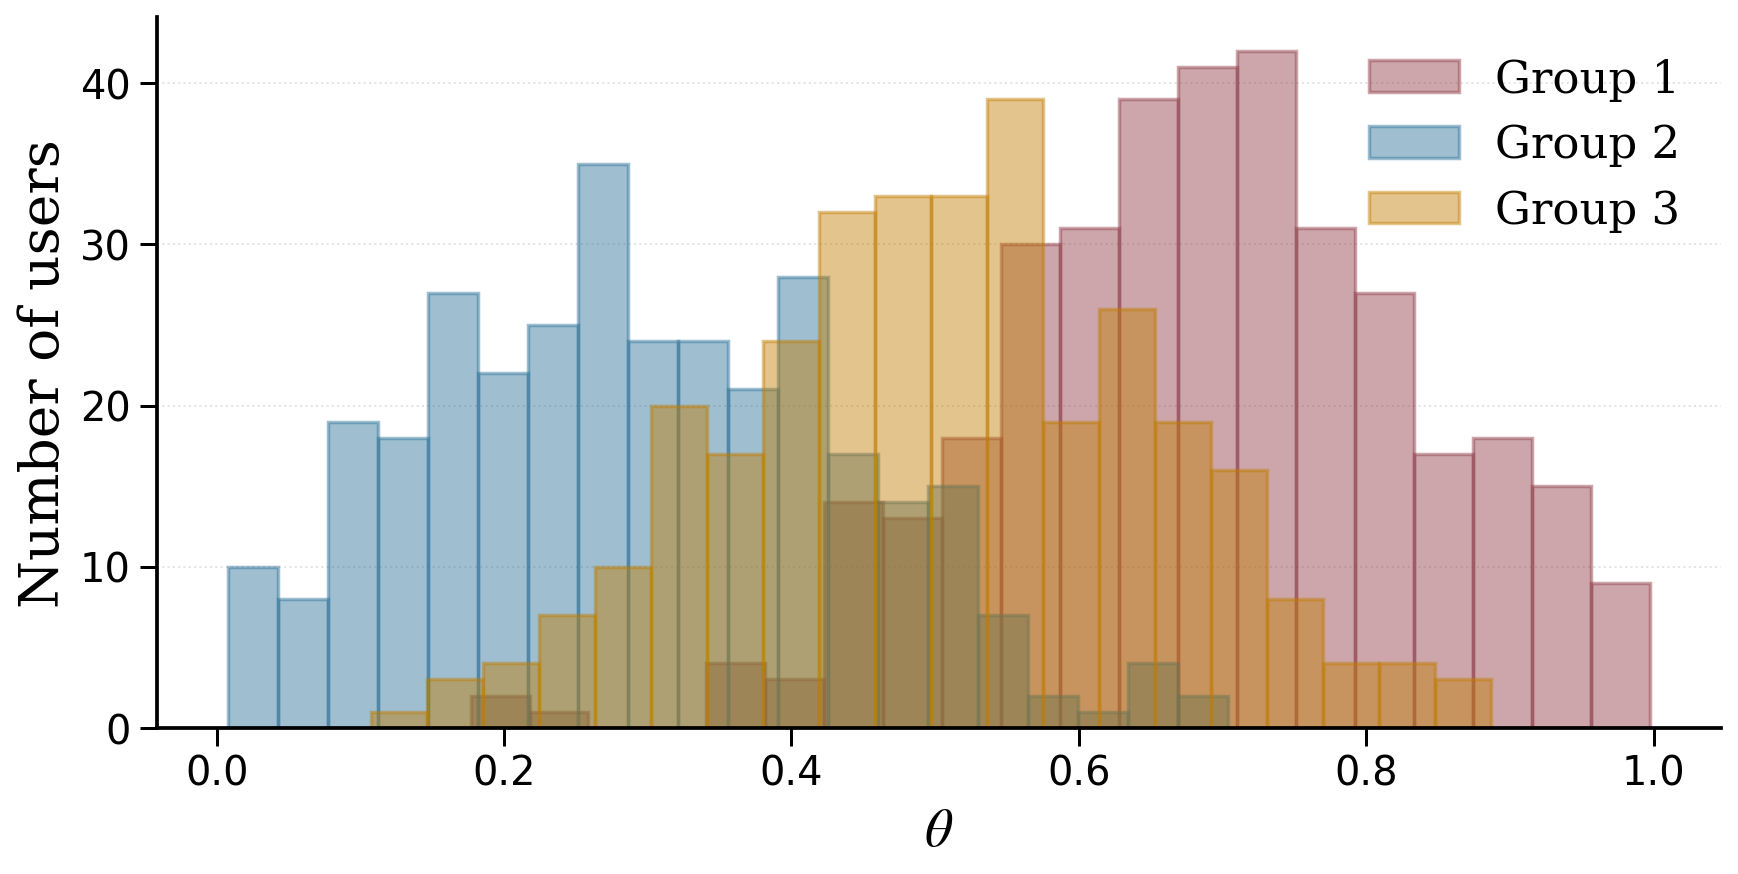

In [10]:
plot_theta_histogram_3groups(initial_population)

# Sampling Feedback Loop

In [11]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [12]:
# Simulación de sampling FL

T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Número de usuarios por iteración
g1_T = []
g2_T = []
g3_T = []

# inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)
n_g3 = sum(u.group == 3 for u in population)


# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}
theta_T_g3 = {}

for i in range(0, T+1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
            
    # consecuencias de la decision (quitar usuario, meter uno nuevo)
    if d == 0:
        population.remove(user)
        if group == 1:
            n_g1 -= 1
        elif group == 2:
            n_g2 -= 1
        else:
            n_g3 -=1
            
        new_user = create_user_homophily_3groups(user_id, n_g1, n_g2, n_g3)
        population.append(new_user)
        
        if new_user.group == 1:
            n_g1 += 1
        elif new_user.group == 2:
            n_g2 += 1
        else:
            n_g3 += 1
            
    count_d1 += (d == 1)    #test
    count_d0 += (d == 0)
        
    # añadir x,y al dataset
    X = np.append(X, [[x]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    g3_T.append(n_g3)
    
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]
        theta_T_g3[i] = [u.theta for u in population if u.group == 3]

In [13]:
# variables de análsis
print(n_g1, n_g2, n_g3)
print(count_d0, count_d1)

688 34 278
824 49177


In [14]:
for i in population:
    if model.predict([[i.theta]])[0] == 1:
        pass 
    else:
        print("No todas las decisiones son d=1.")
# si no imprime nada quiere decir que el modelo, para la población última, 
# siempre predice d=1 (no hay sampling)

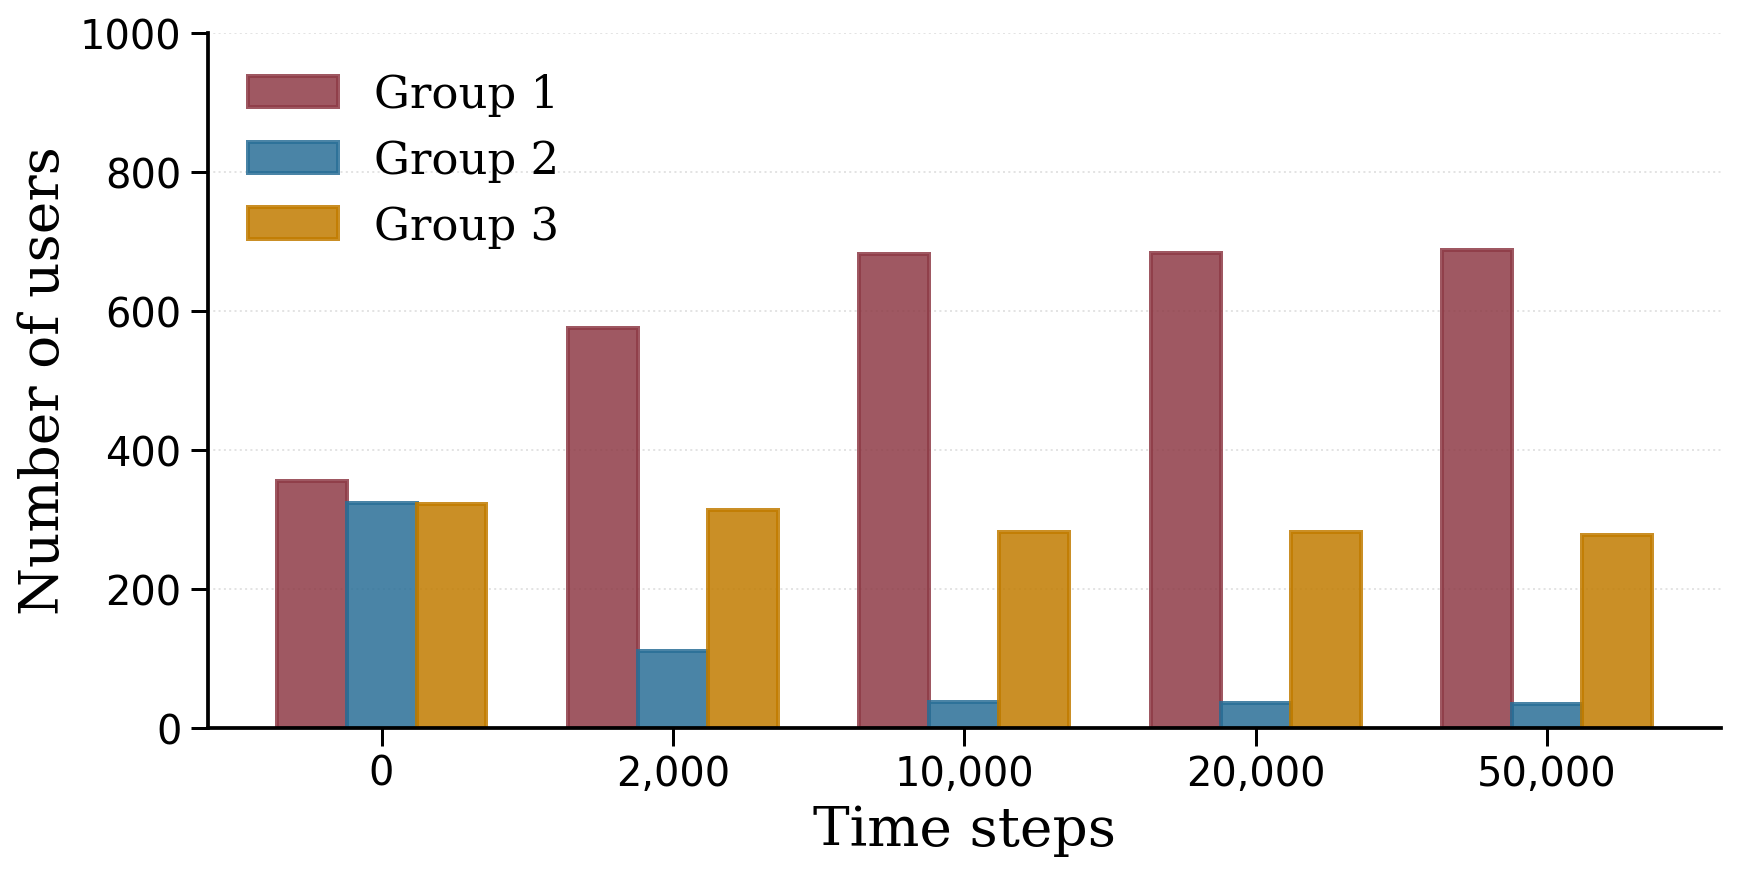

In [15]:
plot_user_checkpoints_3groups(g1_T, g2_T, g3_T, checkpoints)

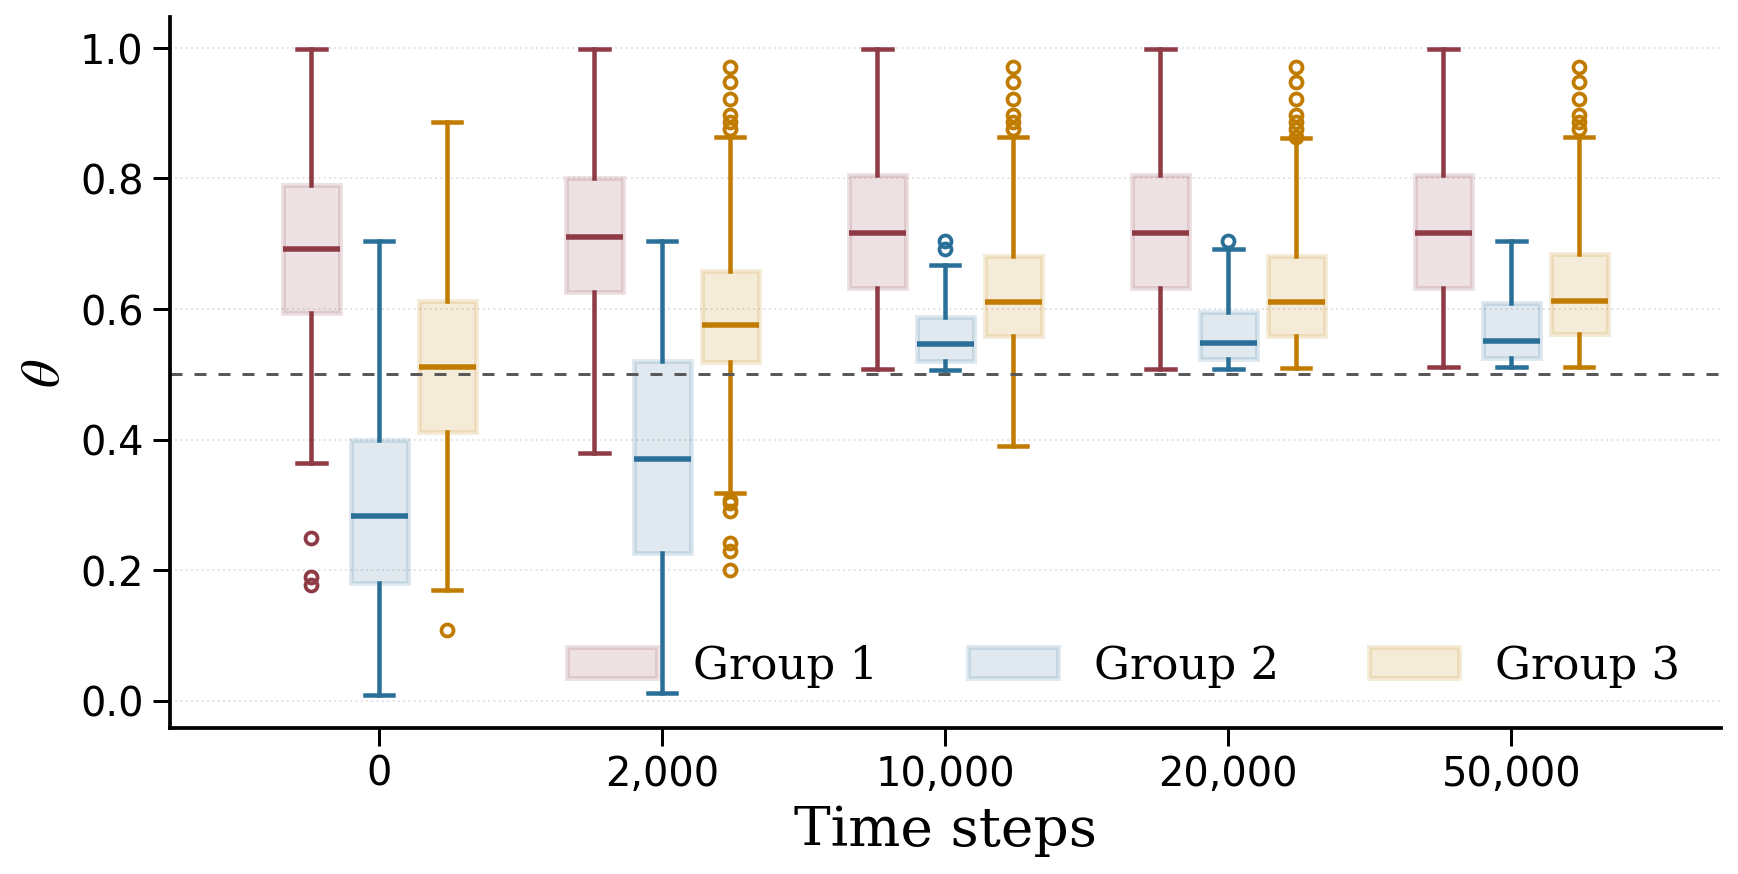

In [16]:
plot_boxplots_3groups(theta_T_g1, theta_T_g2, theta_T_g3, checkpoints, "theta")

# ML Model Feedback Loop

In [17]:
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)
model = copy.deepcopy(initial_noisy_model)
population = copy.deepcopy(initial_population)

In [18]:
# Simulación de ML Mode FL
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

error_T_g1 = {}
error_T_g2 = {}
error_T_g3 = {}

# Variables que creo para análsis
count_d1 = 0
count_d0 = 0

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5

    
    # consecuencias de la decision (solo se añade el par x,y si d=1)
    if d == 1:
        X = np.append(X, [[x]], axis=0)
        y = np.append(y, outcome)
    
        # reentreno el modelo solo si cambio dataset
        model = train_LR(X, y)
    
    count_d1 += (d == 1)    #test
    count_d0 += (d == 0)
    
    
    # guardo error de predicción (y.pred_proba - E(y)) en checkpoints
    if i in checkpoints:
        err_g1, err_g2, err_g3 = error_3groups(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2
        error_T_g3[i] = err_g3

In [19]:
# variables de análsis
print(count_d0, count_d1)

22492 27509


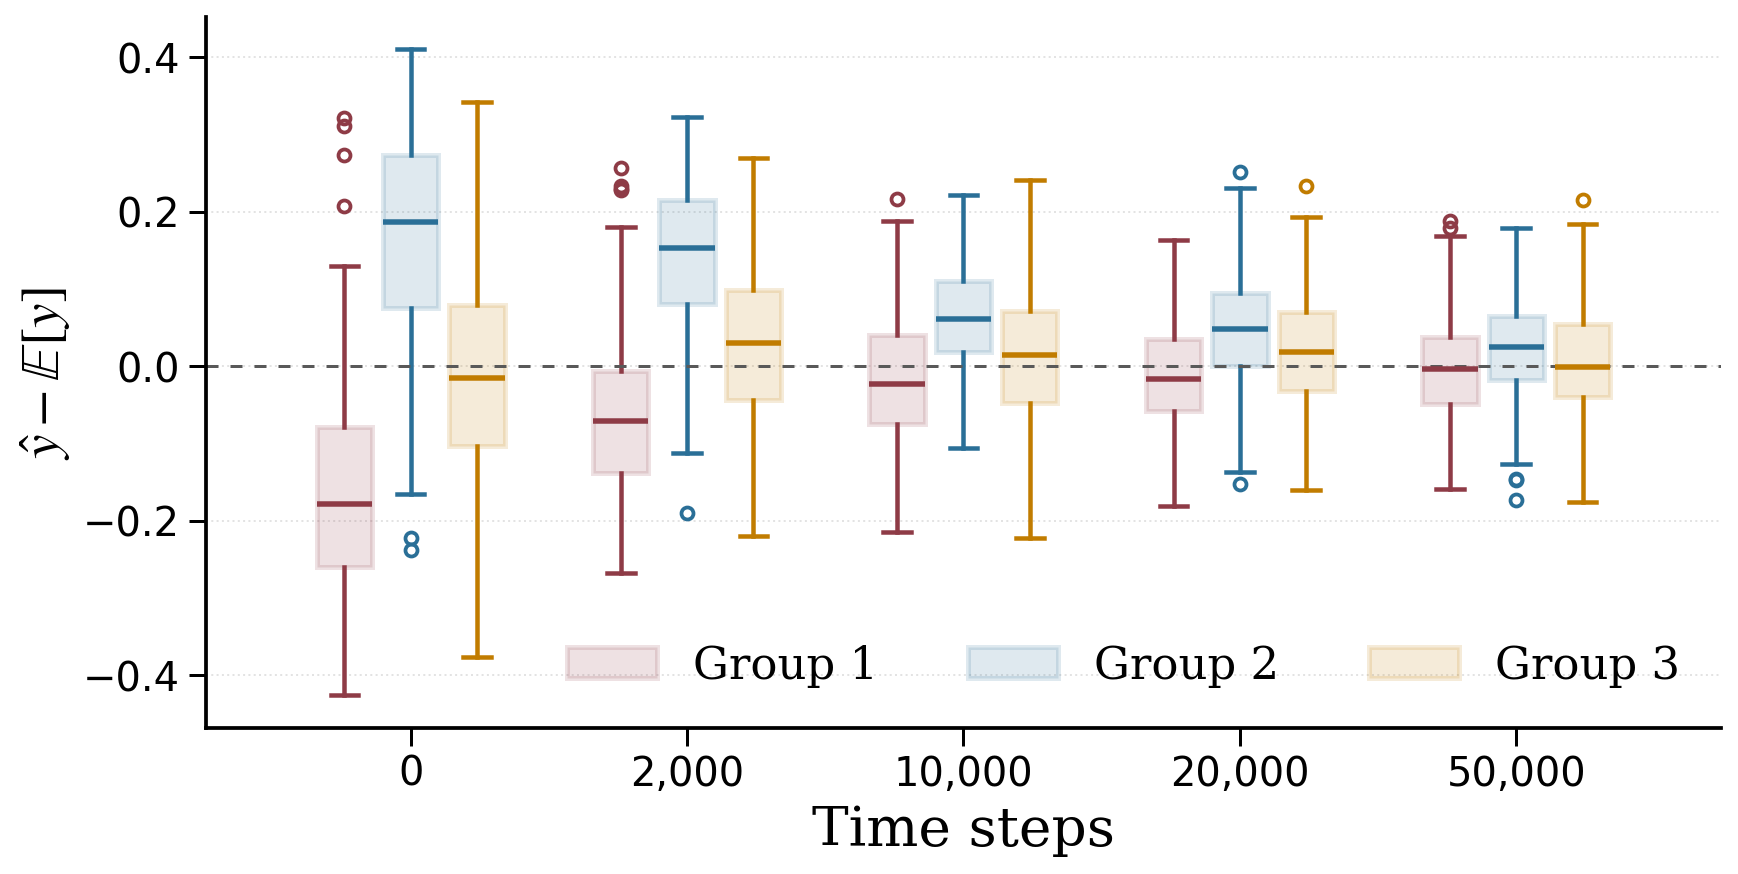

In [20]:
plot_boxplots_3groups(error_T_g1, error_T_g2, error_T_g3, checkpoints, "error")

# Coupled Feedback Loop

In [21]:
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)
model = copy.deepcopy(initial_noisy_model)
population = copy.deepcopy(initial_population)

In [22]:
# Simulación de ML Model y Sampling FLs acoplados
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Error por iteración
error_T_g1 = {}
error_T_g2 = {}
error_T_g3 = {}

# Número de usuarios por iteración
g1_T = []
g2_T = []
g3_T = []

# inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)
n_g3 = sum(u.group == 3 for u in population)

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}
theta_T_g3 = {}


for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5

    
    # consecuencias de la decision (solo se añade el par x,y si d=1, si d=0 usuario se va de la plataforma )
    if d == 0:
        population.remove(user)
        if group == 1:
            n_g1 -= 1
        elif group == 2:
            n_g2 -= 1
        else:
            n_g3 -= 1
            
        new_user = create_user_homophily_3groups(user_id, n_g1, n_g2, n_g3)
        population.append(new_user)
        
        if new_user.group == 1:
            n_g1 += 1
        elif new_user.group == 2:
            n_g2 += 1
        else:
            n_g3 += 1
            
    elif d == 1:
        X = np.append(X, [[x]], axis=0)
        y = np.append(y, outcome)
        # reentreno el modelo solo si cambio dataset
        model = train_LR(X, y)
        
    count_d1 += (d == 1)
    count_d0 += (d == 0)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    g3_T.append(n_g3)
    
    # guardo error de predicción (y.pred_proba - E(y)) en checkpoints
    if i in checkpoints:
        err_g1, err_g2, err_g3 = error_3groups(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2
        error_T_g3[i] = err_g3
        
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]
        theta_T_g3[i] = [u.theta for u in population if u.group == 3]

In [23]:
# variables de análsis
print(n_g1, n_g2)
print(count_d0, count_d1)

677 36
819 49182


In [24]:
for i in population:
    if model.predict([[i.theta]])[0] == 1:
        pass 
    else:
        print("No todas las decisiones son d=1.")
# si no imprime nada quiere decir que el modelo, para la población última, 
# siempre predice d=1 (no hay sampling)

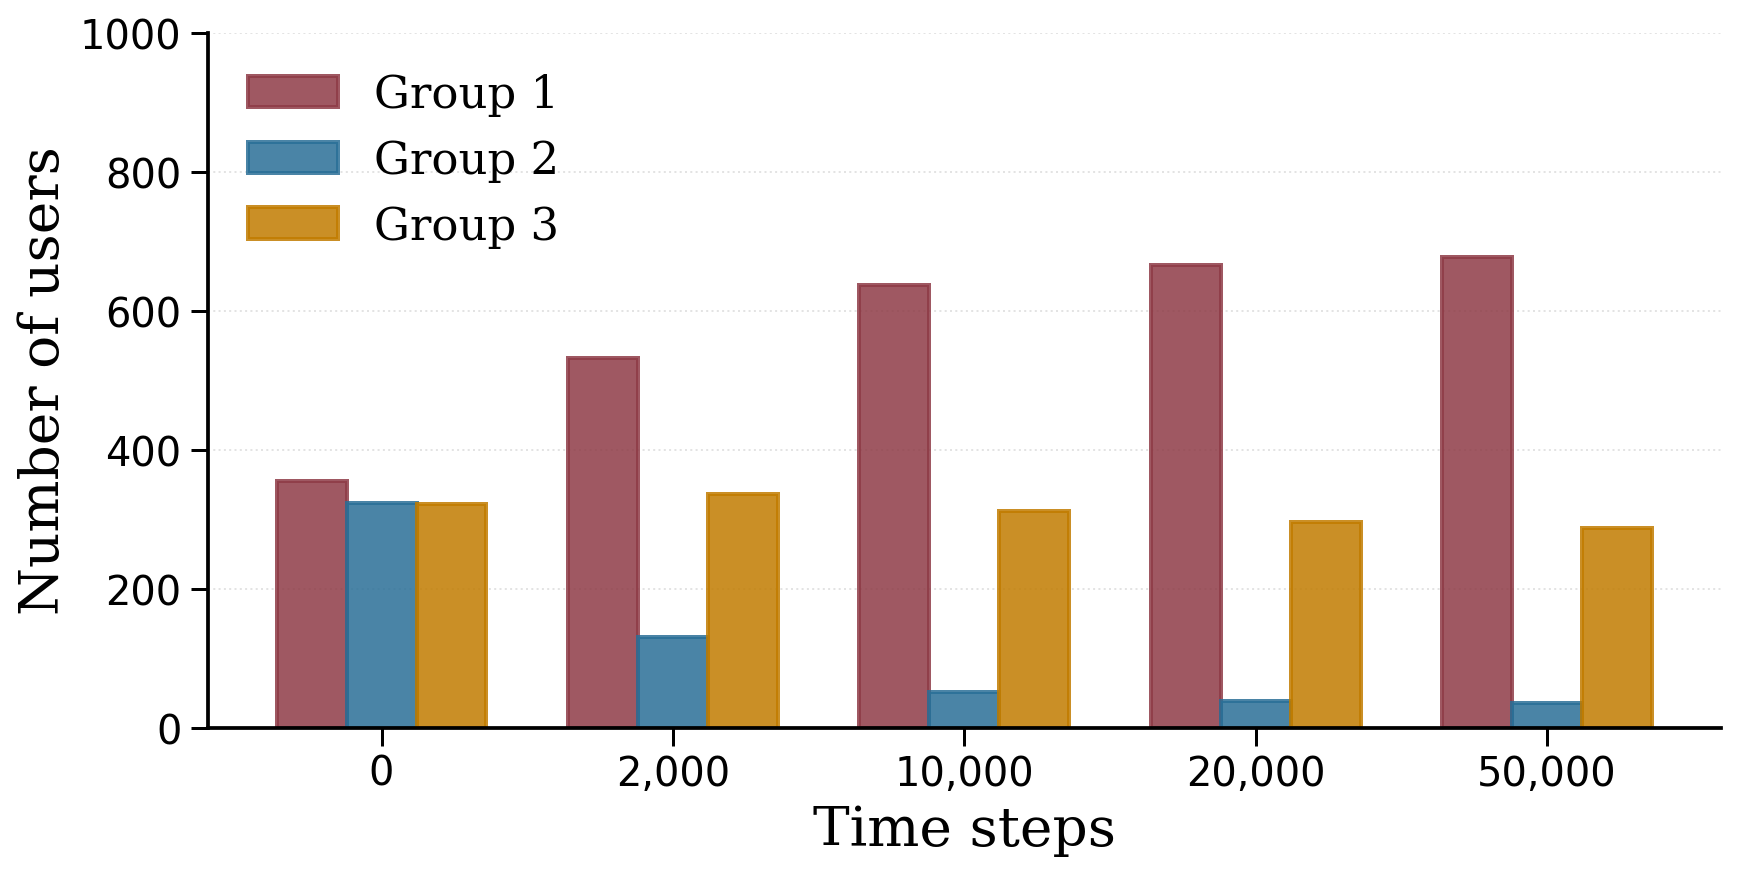

In [25]:
plot_user_checkpoints_3groups(g1_T, g2_T, g3_T, checkpoints)

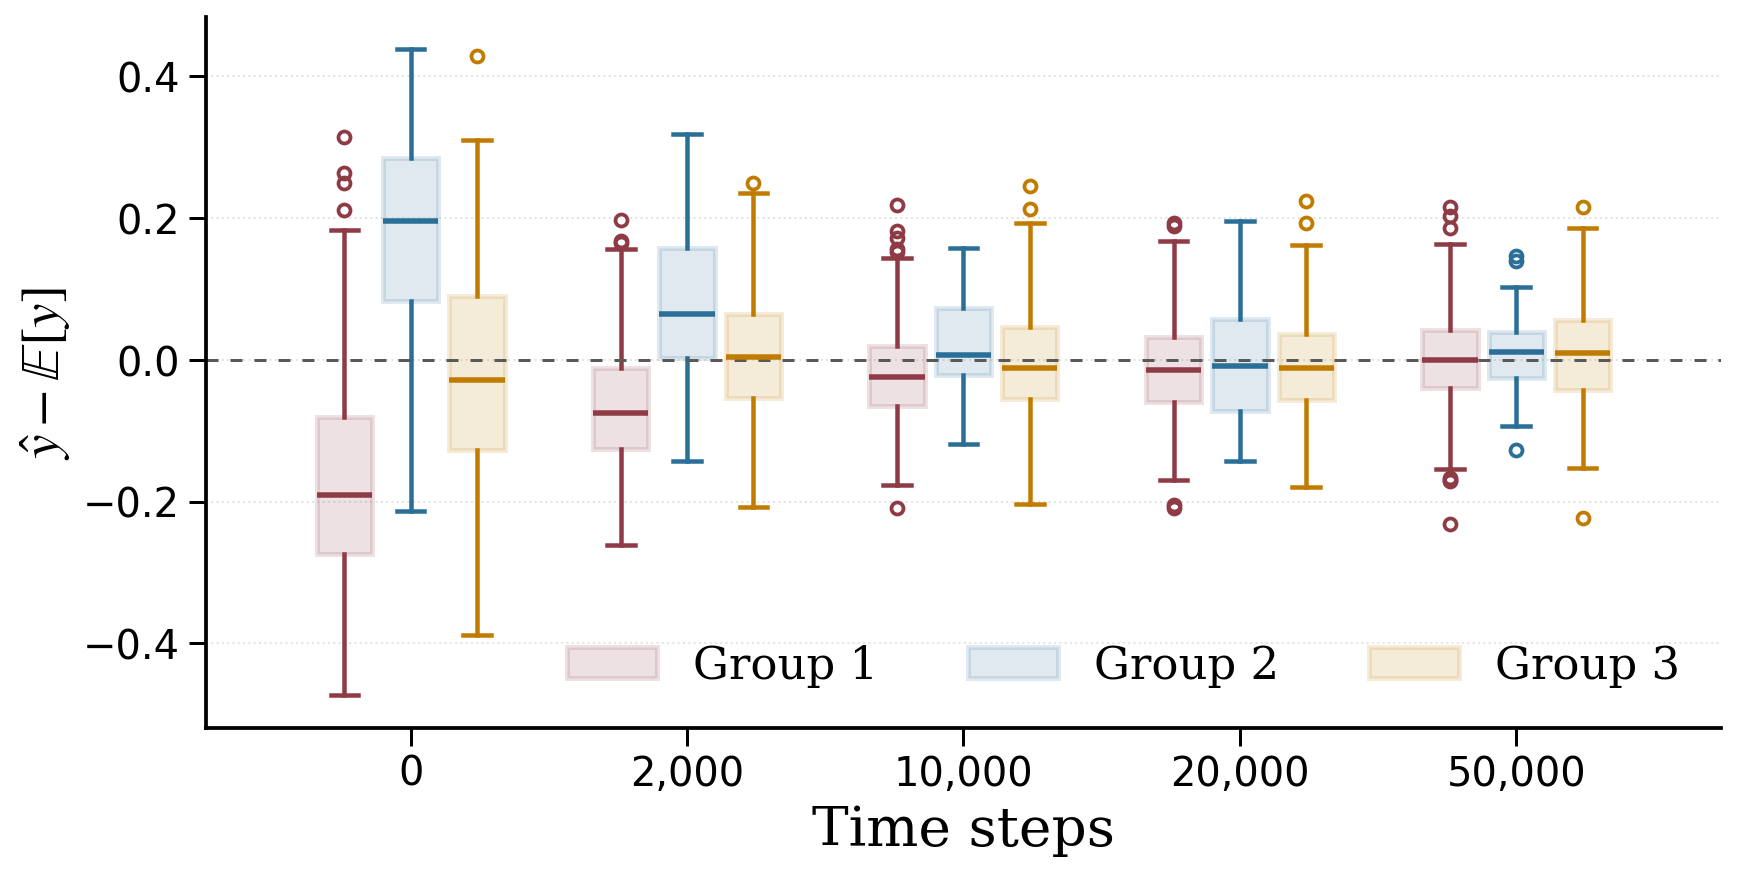

In [26]:
plot_boxplots_3groups(error_T_g1, error_T_g2, error_T_g3, checkpoints, "error")

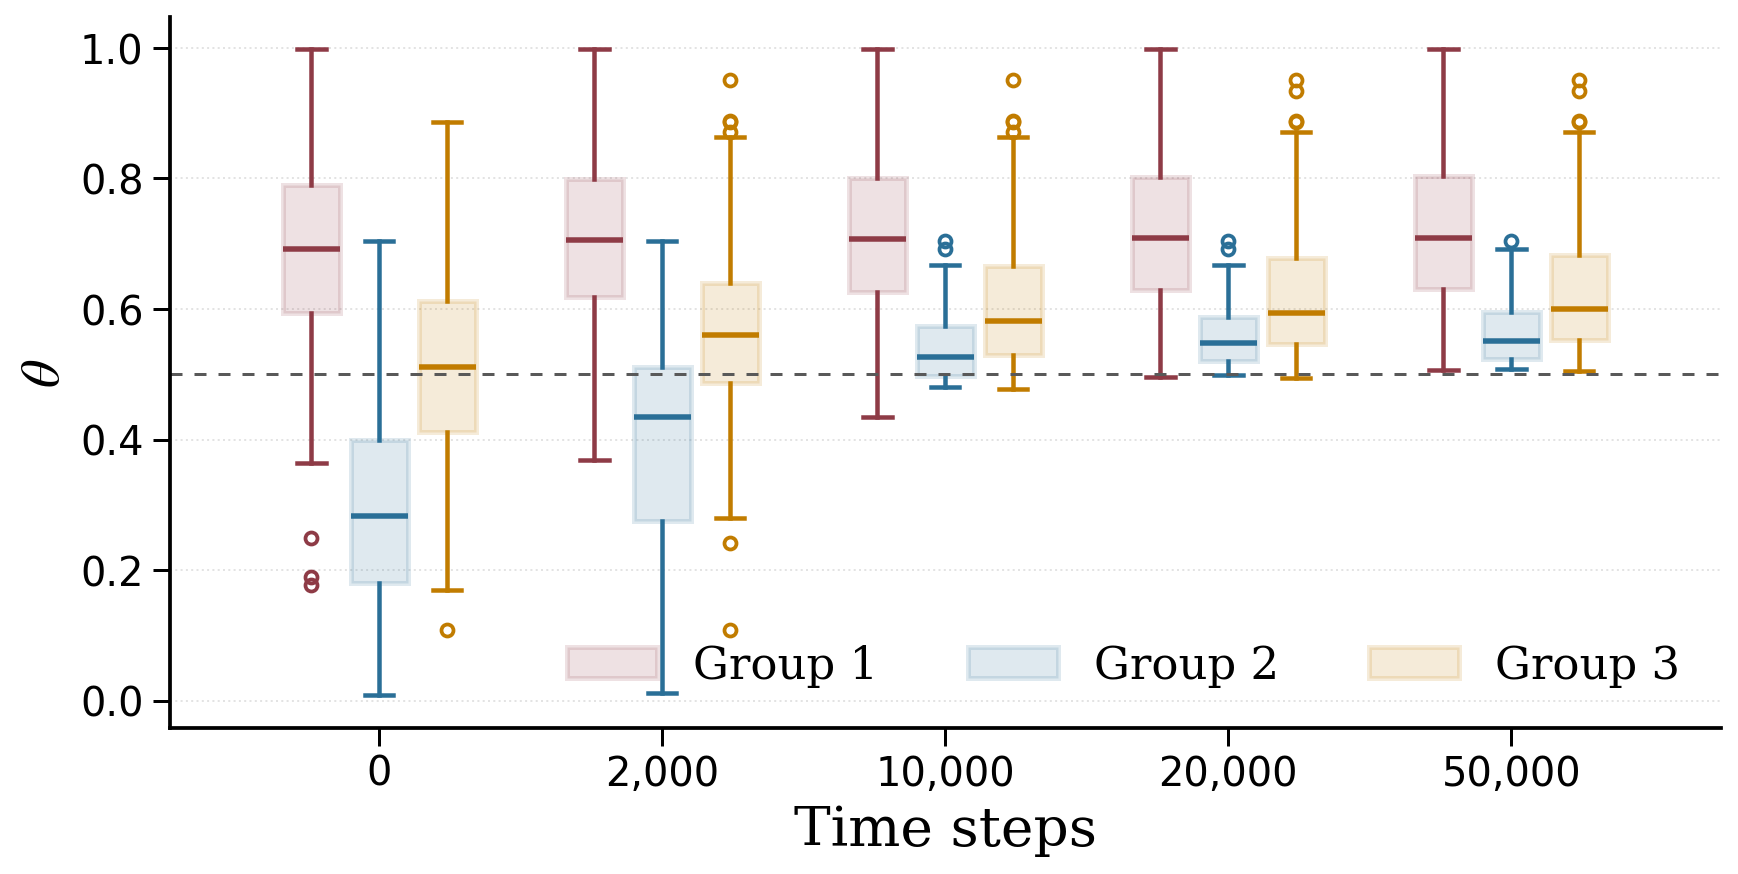

In [27]:
plot_boxplots_3groups(theta_T_g1, theta_T_g2, theta_T_g3, checkpoints, "theta")